1. Can we use Bagging for regression problems?
  - Yes

2. What is the difference between multiple model training and single model training?
  - In multiple model training, we take answers from all models to get final answer.
  - In single model training, we get final answer from one model.

3. Explain the concept of feature randomness in Random Forest.
  - In random forest, we create multiple decision trees and give them different samples of features which is randomly selected.

4. What is OOB (Out-of-Bag) Score?
  - While bagging, some train data might not be taken in any D.T. So this data can be used as test data to get accuracy.

5. How can you measure the importance of features in a Random Forest model?
  - Mean Decrease in Impurity (MDI)
    - Based on how much each feature reduces impurity (Gini / MSE) across all trees.
    - Fast, but biased toward high-cardinality features.

6. Explain the working principle of a Bagging Classifier.
  - It takes samples of data or features randomly and gives it to each D.T.

7. How do you evaluate a Bagging Classifier’s performance?
  - We can evaluate it's performance using oob score and accuracy score on test data.

8. How does a Bagging Regressor work?
  - It averages the answers got from every model to provide final answer.

9. What is the main advantage of ensemble techniques?
  - The main advantage of ensemble techniques is that they improve model performance by combining multiple models.

10. What is the main challenge of ensemble methods?
  - The main challenge of ensemble methods is increased complexity.
  - Harder to interpret, more hyperparameters to tune.

11. Explain the key idea behind ensemble techniques.
  - Combine multiple models to get better accuracy and robustness than a single model.

12. What is a Random Forest Classifier?
  - A Random Forest Classifier is an ensemble model that builds many decision trees and predicts the class by majority voting.

13. What are the main types of ensemble techniques?
  - Bagging, boosting, stacking.

14. What is ensemble learning in machine learning?
  - Ensemble learning is a technique that combines multiple models to improve accuracy and robustness.

15. When should we avoid using ensemble methods?
  - Avoid ensemble methods when interpretability, low latency, or limited compute is required.

16. How does Bagging help in reducing overfitting?
  - Bagging reduces overfitting by training models on different bootstrap samples and averaging predictions, which reduces variance.

17. Why is Random Forest better than a single Decision Tree?
  - Random Forest is better because it reduces overfitting, lowers variance, and gives more stable and accurate predictions.

18. What is the role of bootstrap sampling in Bagging?
  - Bootstrap sampling creates multiple different training datasets by sampling with replacement, enabling diverse models and variance reduction.

19. What are some real-world applications of ensemble techniques?
  - Ensemble techniques are used in fraud detection, credit scoring, recommendation systems, medical diagnosis, and spam detection.

20. What is the difference between Bagging and Boosting?
  - In bagging models are trained parallely.
  - In boosting models are trained sequentially.

In [ ]:
# 21. Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9


In [ ]:
# 22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE)
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=100, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 6967.863746774799


In [ ]:
# 23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

feature_importances = model.feature_importances_
print("Feature importance scores")
print(feature_importances)

Feature importance scores
[0.04870337 0.01359088 0.05326975 0.04755501 0.00728533 0.01394433
 0.06800084 0.10620999 0.00377029 0.00388577 0.02013892 0.00472399
 0.01130301 0.02240696 0.00427091 0.00525322 0.00938583 0.00351326
 0.00401842 0.00532146 0.07798688 0.02174901 0.06711483 0.15389236
 0.01064421 0.02026604 0.0318016  0.14466327 0.01012018 0.00521012]


In [ ]:
# 24. Train a Random Forest Regressor and compare its performance with a single Decision Tree
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X, y = make_regression(n_samples=1000, n_features=20, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, dt_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Decision Tree R2: 0.49133234450890195
Random Forest R2: 0.8163814678007817


In [ ]:
# 25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
model.fit(X_train, y_train)

print("OOB Score:", model.oob_score_)

OOB Score: 0.89


In [ ]:
# 26. Train a Bagging Classifier using SVM as a base estimator and print accuracy
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(1000, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = BaggingClassifier(estimator=SVC(), n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.85


In [ ]:
# 27. Train a Random Forest Classifier with different numbers of trees and compare accuracy
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for n in [10, 50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    print(f"Trees: {n}, Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Trees: 10, Accuracy: 0.8550
Trees: 50, Accuracy: 0.8800
Trees: 100, Accuracy: 0.9000
Trees: 200, Accuracy: 0.8900


In [ ]:
# 28. Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_auc_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = BaggingClassifier(estimator=LogisticRegression(), n_estimators=50, random_state=42)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
print("AUC:", roc_auc_score(y_test, y_proba))

AUC: 0.9219173952366597


In [ ]:
# 29. Train a Random Forest Regressor and analyze feature importance scores
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X, y = make_regression(n_samples=1000, n_features=20, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

feature_importances = model.feature_importances_
print("Feature importance scores")
print(feature_importances)

Feature importance scores
[0.14673674 0.23695389 0.00944071 0.00862947 0.17222591 0.00782465
 0.10498867 0.00963034 0.00833025 0.00753402 0.00875583 0.02556548
 0.00796295 0.00784358 0.00851671 0.01822286 0.00866213 0.18477808
 0.00944164 0.00795608]


In [ ]:
# 30. Train an ensemble model using both Bagging and Random Forest and compare accuracy
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(1000, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

bagging = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, bagging_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Bagging Accuracy: 0.9
Random Forest Accuracy: 0.9


In [1]:
# 31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)

param_grid = {"n_estimators": [50, 100],
              "max_depth": [None, 10, 20],
              "min_samples_split": [2, 5]}

grid = GridSearchCV(rf, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Accuracy: 0.89375


In [2]:
# 32. Train a Bagging Regressor with different numbers of base estimators and compare performance
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=1000, n_features=20, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for n in [10, 50, 100, 200]:
    model = BaggingRegressor(DecisionTreeRegressor(), n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Estimators: {n}, MSE: {mean_squared_error(y_test, y_pred):.4f}")

Estimators: 10, MSE: 8029.1210
Estimators: 50, MSE: 7347.9366
Estimators: 100, MSE: 7090.7961
Estimators: 200, MSE: 6746.2979


In [6]:
# 33. Train a Random Forest Classifier and analyze misclassified samples
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mis_idx = np.where(y_test != y_pred)[0]
print("Number of misclassified samples:", len(mis_idx))

for i in mis_idx[:5]:
    print("True:", y_test[i], "Pred:", y_pred[i])

Number of misclassified samples: 20
True: 1 Pred: 0
True: 0 Pred: 1
True: 1 Pred: 0
True: 0 Pred: 1
True: 0 Pred: 1


In [7]:
# 34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42)
bag.fit(X_train, y_train)
bag_pred = bag.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Bagging Accuracy:", accuracy_score(y_test, bag_pred))

Decision Tree Accuracy: 0.875
Bagging Accuracy: 0.9


In [9]:
# 35. Train a Random Forest Classifier and visualize the confusion matrix
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix
[[88  5]
 [15 92]]


In [10]:
# 36. Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

estimators = [
    ("dt", DecisionTreeClassifier()),
    ("svm", SVC(probability=True)),
    ("lr", LogisticRegression())
]

stack = StackingClassifier(estimators, final_estimator=LogisticRegression())

stack.fit(X_train, y_train)
y_pred = stack.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))

Stacking Accuracy: 0.86


In [14]:
# 37. Train a Random Forest Classifier and print the top 5 most important features
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
top5 = np.argsort(importances)[-5:][::-1]

print("Top 5 important features:")
for i in top5:
    print(f"Feature {i}: {importances[i]:.4f}")

Top 5 important features:
Feature 5: 0.3631
Feature 18: 0.1773
Feature 1: 0.1018
Feature 14: 0.0756
Feature 11: 0.0257


In [15]:
# 38. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42)

bag.fit(X_train, y_train)
y_pred = bag.predict(X_test)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Precision: 0.967741935483871
Recall: 0.8411214953271028
F1-score: 0.9


In [16]:
# 39. Train a Random Forest Classifier and analyze the effect of max_depth on accuracy
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for d in [None, 5, 10, 20]:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    print(f"max_depth={d}, Accuracy={accuracy_score(y_test, y_pred):.4f}")

max_depth=None, Accuracy=0.9000
max_depth=5, Accuracy=0.8800
max_depth=10, Accuracy=0.8850
max_depth=20, Accuracy=0.9000


In [18]:
# 40. Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare
# performance
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=1000, n_features=20, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

bag_dt = BaggingRegressor(DecisionTreeRegressor(), n_estimators=100, random_state=42)
bag_dt.fit(X_train, y_train)
dt_pred = bag_dt.predict(X_test)

bag_knn = BaggingRegressor(KNeighborsRegressor(), n_estimators=100, random_state=42)
bag_knn.fit(X_train, y_train)
knn_pred = bag_knn.predict(X_test)

print("Bagging + Decision Tree MSE:", mean_squared_error(y_test, dt_pred))
print("Bagging + KNN MSE:", mean_squared_error(y_test, knn_pred))

Bagging + Decision Tree MSE: 7105.1449062114325
Bagging + KNN MSE: 14112.2950412184


In [20]:
# 41. Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_proba = rf.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

ROC-AUC Score: 0.9379459350819013


In [21]:
# 42. Train a Bagging Classifier and evaluate its performance using cross-validation
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42)

scores = cross_val_score(bag, X, y, cv=5, scoring="accuracy")

print("CV Accuracies:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Accuracies: [0.94  0.915 0.895 0.92  0.88 ]
Mean CV Accuracy: 0.9099999999999999


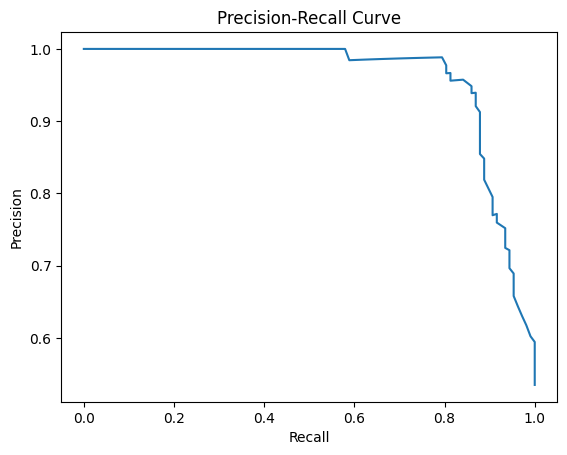

In [24]:
# 43. Train a Random Forest Classifier and plot the Precision-Recall curve
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_scores = rf.predict_proba(X_test)[:, 1]

precision, recall, threshold = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [26]:
# 44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression()

stack = StackingClassifier(estimators=[("rf", rf), ("lr", lr)],final_estimator=lr)

rf.fit(X_train, y_train)
stack.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
stack_pred = stack.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))

Random Forest Accuracy: 0.9
Stacking Accuracy: 0.89


In [27]:
# 45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=1000, n_features=20, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for ms in [0.3, 0.5, 0.7, 1.0]:
    bag = BaggingRegressor(DecisionTreeRegressor(), n_estimators=100, max_samples=ms, random_state=42)
    bag.fit(X_train, y_train)
    y_pred = bag.predict(X_test)
    print(f"max_samples={ms}, MSE={mean_squared_error(y_test, y_pred):.4f}")

max_samples=0.3, MSE=8658.5151
max_samples=0.5, MSE=7334.6696
max_samples=0.7, MSE=7257.5788
max_samples=1.0, MSE=7105.1449
